In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
import warnings

In [2]:
import plotly.express as px

In [3]:
df = pd.read_excel("C:/Users/kumar/Downloads/Bank loan/financial_loan_data_excel.xlsx")

### Meta Data of data


In [4]:
print("No of Rows:",df.shape[0])

No of Rows: 38576


In [5]:
print("No of Columns:", df.shape[1])

No of Columns: 24


df.info

### Data Types

In [6]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [7]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total loan Applications


In [8]:
total_loan_applications = df["id"].count()
print("Total Loan Applications:",total_loan_applications)

Total Loan Applications: 38576


### MTD Total loan Applications


In [9]:
latest_issue_date = df["issue_date"].max() 

latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df["issue_date"].dt.year == latest_year) & (df["issue_date"].dt.month == latest_month)]
mtd_loan_applications = mtd_data["id"].count()


print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

MTD Loan Applications (for December 2021): 4314


In [10]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M". format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD FUNDED AMOUNT


In [11]:
latest_issue_date = df["issue_date"].max() 

latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df["issue_date"].dt.year == latest_year) & (df["issue_date"].dt.month == latest_month)]
mtd_funded_amount = mtd_data["loan_amount"].sum()
mtd_funded_Amount_millions = mtd_funded_amount/1000000


print("MTD Funded Amount:${:.2f}M".format(mtd_funded_Amount_millions))

MTD Funded Amount:$53.98M


### Total Amount Received 

In [12]:
total_amount_received = df["total_payment"].sum()
total_amount_received_millions = total_funded_amount/1000000
print("Total Amount Received: ${:.2f}M".format(total_amount_received_millions))

Total Amount Received: $435.76M


### MTD Total Amount Received 

In [13]:
latest_issue_date = df["issue_date"].max()

latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[
    (df["issue_date"].dt.year == latest_year) &
    (df["issue_date"].dt.month == latest_month)
]

mtd_amount_received = mtd_data["total_payment"].sum()

mtd_amount_received_millions = mtd_amount_received / 1000000

print("MTD Received Amount: ${:.2f}M".format(mtd_amount_received_millions))


MTD Received Amount: $58.07M


### Avg Interest Rate

In [14]:
avg_interest_rate = df['int_rate'].mean()*100
print("Avg Int Rate:{:.2f}%".format( avg_interest_rate))

Avg Int Rate:12.05%


### Avg DTI

In [15]:
avg_dti = df['dti'].mean()*100
print("Avg DTI:{:.2f}%".format( avg_dti))

Avg DTI:13.33%


### Good Loans

In [16]:
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()
good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Amount Received (in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))


Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Amount Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


### Bad Loans

In [17]:

bad_loans = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()
bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
good_loan_received = bad_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Amount Received (in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))


Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Amount Received (in Millions): $37.28M
Percentage of Good Loan Applications: 86.18%


### Monthly Trends by Issue Date for Total Funded Amount

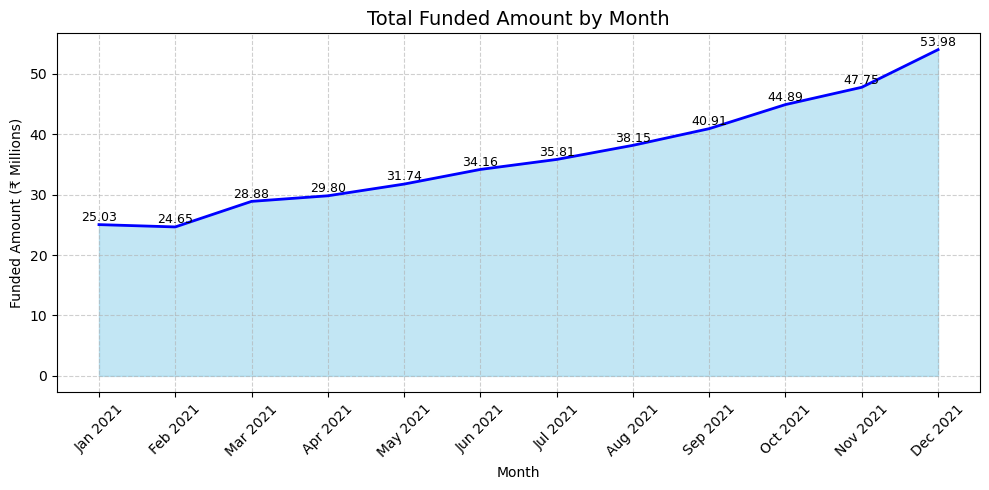

In [18]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1000000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='skyblue',
    alpha=0.5
)

plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='blue',
    linewidth=2
)

for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.1,
             f"{row['loan_amount_millions']:.2f}",
             ha='center', va='bottom',
             fontsize=9, rotation=0, color='black')

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount (₹ Millions)')
plt.xticks(ticks=range(len(monthly_funded)),
           labels=monthly_funded['month_name'],
           rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends By Issue Date Total Amount Received

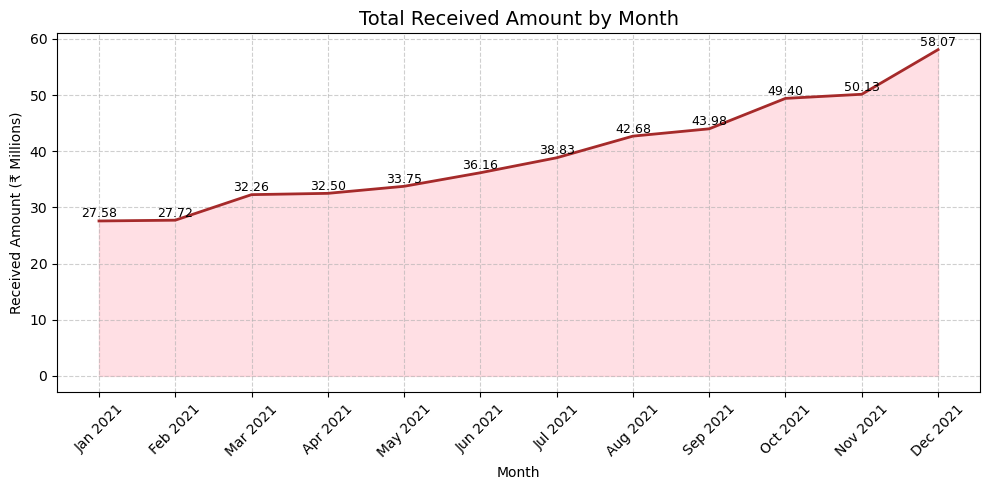

In [19]:
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1000000)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='pink',
    alpha=0.5
)

plt.plot(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='brown',
    linewidth=2
)

for i, row in monthly_received.iterrows():
    plt.text(i, row['received_amount_millions'] + 0.1,
             f"{row['received_amount_millions']:.2f}",
             ha='center', va='bottom',
             fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount (₹ Millions)')
plt.xticks(ticks=range(len(monthly_received)),
           labels=monthly_received['month_name'],
           rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends By Issue Date for Total Loan Applications

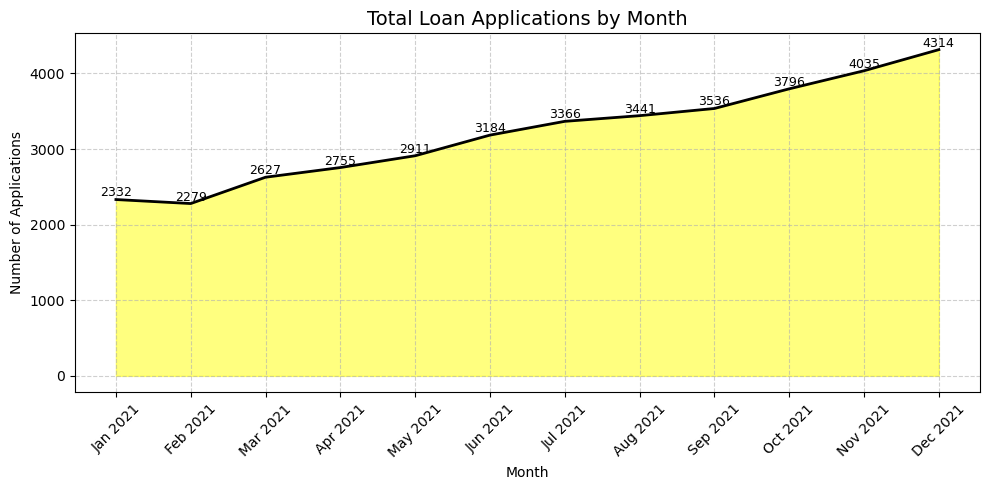

In [20]:
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['id']
      .count()
      .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))

plt.fill_between(monthly_applications['month_name'],
                 monthly_applications['loan_applications_count'],
                 color='yellow', alpha=0.5)

plt.plot(monthly_applications['month_name'],
         monthly_applications['loan_applications_count'],
         color='black', linewidth=2)

for i, row in monthly_applications.iterrows():
    plt.text(i, row['loan_applications_count'] + 0.5,
             f"{row['loan_applications_count']}",
             ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_applications)),
           labels=monthly_applications['month_name'],
           rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total funded Amount

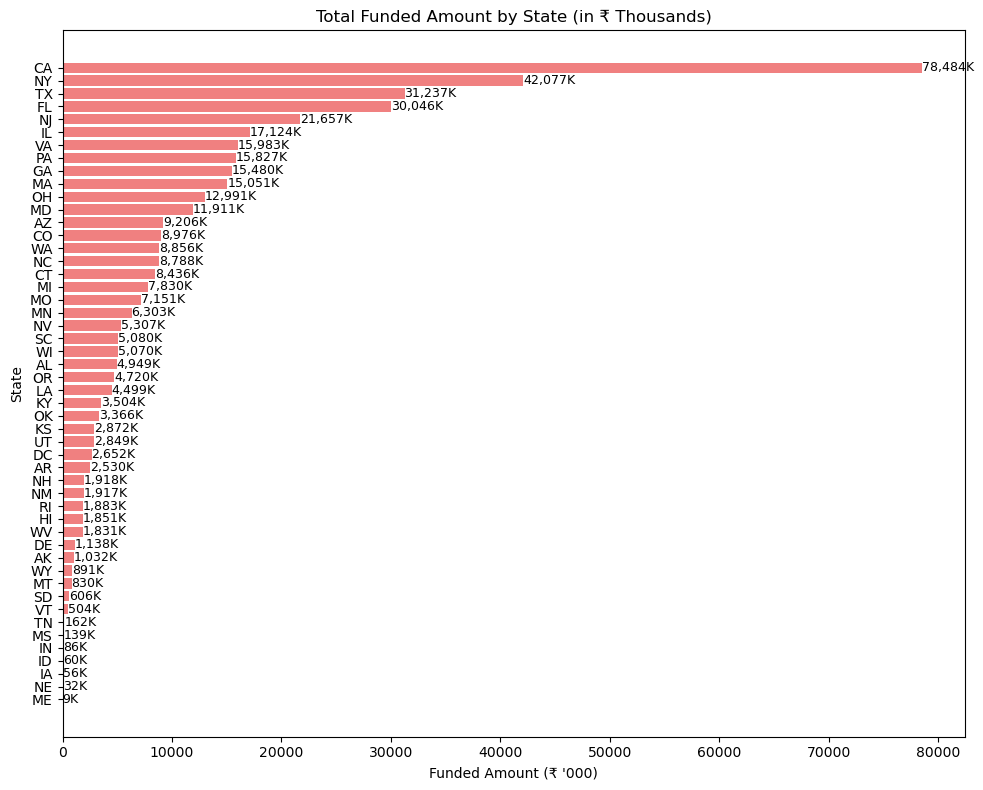

In [21]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_funding_thousands.index,
                state_funding_thousands.values,
                color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K',
             va='center',
             fontsize=9)

plt.title('Total Funded Amount by State (in ₹ Thousands)')
plt.xlabel('Funded Amount (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Amount Received

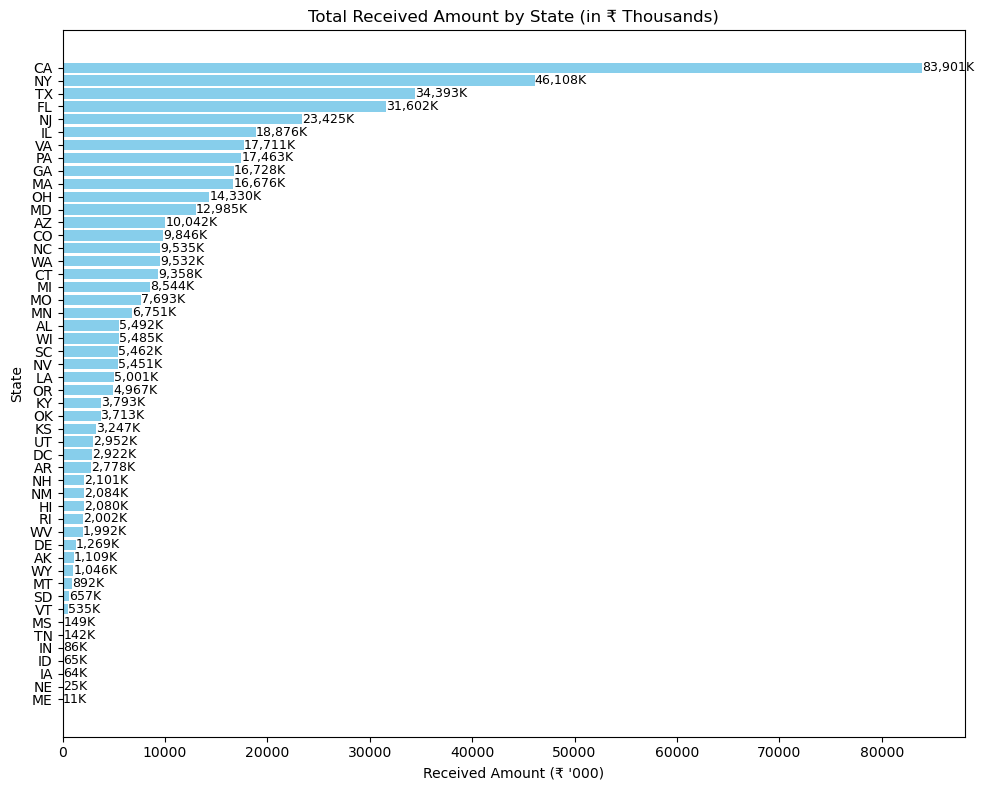

In [22]:
state_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_received_thousands = state_received / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_received_thousands.index,
                state_received_thousands.values,
                color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K',
             va='center',
             fontsize=9)

plt.title('Total Received Amount by State (in ₹ Thousands)')
plt.xlabel('Received Amount (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Loan Applications

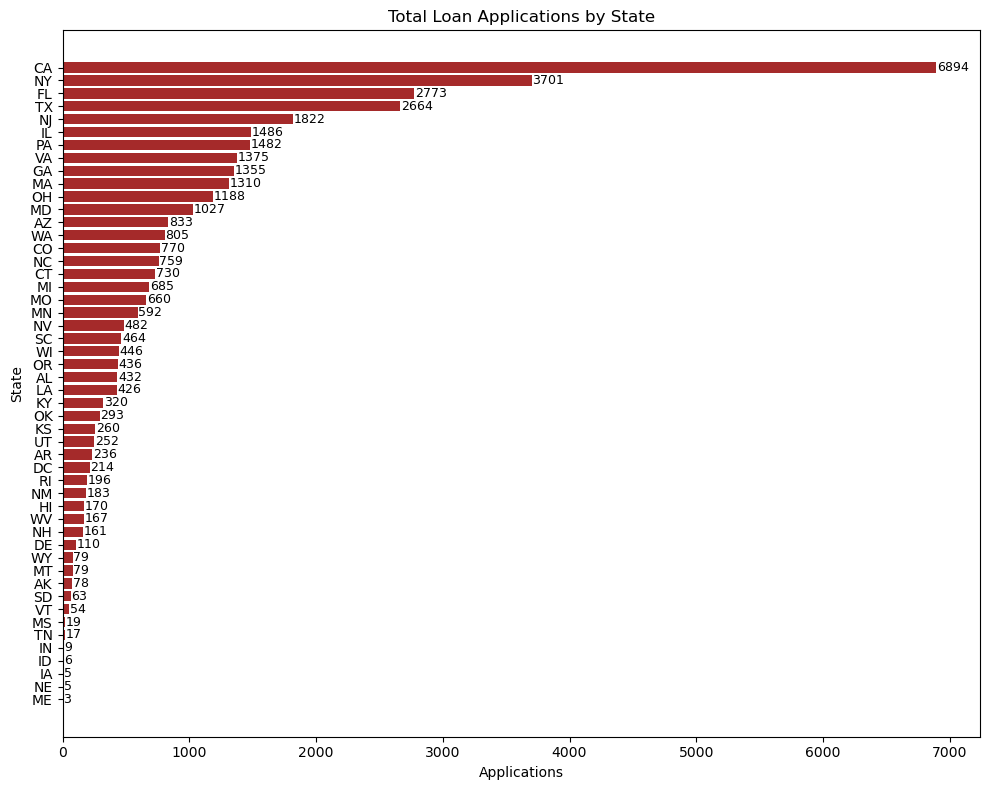

In [53]:
state_applications = df.groupby('address_state')['id'].count().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(state_applications.index,
                state_applications.values,
                color='brown')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height() / 2,
             f'{int(width)}',
             va='center',
             fontsize=9)

plt.title('Total Loan Applications by State')
plt.xlabel('Applications')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

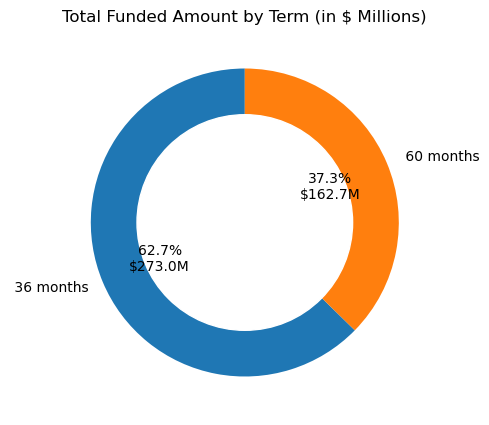

In [24]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5, 5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()

### Loan Term Analysis by Total Amount Received

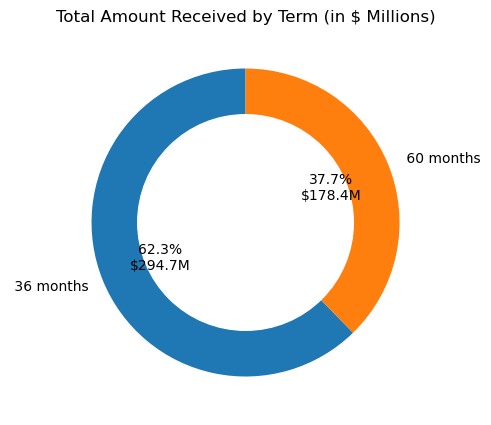

In [52]:
term_amount_millions = df.groupby('term')['total_payment'].sum() / 1000000

plt.figure(figsize=(5, 5))
plt.pie(
    term_amount_millions,
    labels=term_amount_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_amount_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Amount Received by Term (in $ Millions)")
plt.show()

### Loan Term Analysis by Total Loan Application

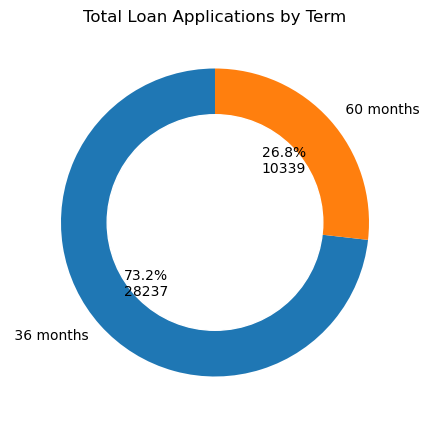

In [51]:
term_applications = df.groupby('term')['id'].count()

plt.figure(figsize=(5, 5))
plt.pie(
    term_applications,
    labels=term_applications.index,
    autopct=lambda p: f"{p:.1f}%\n{p*sum(term_applications)/100:.0f}",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Loan Applications by Term")
plt.show()

### Employee Length By Total Funded Amount

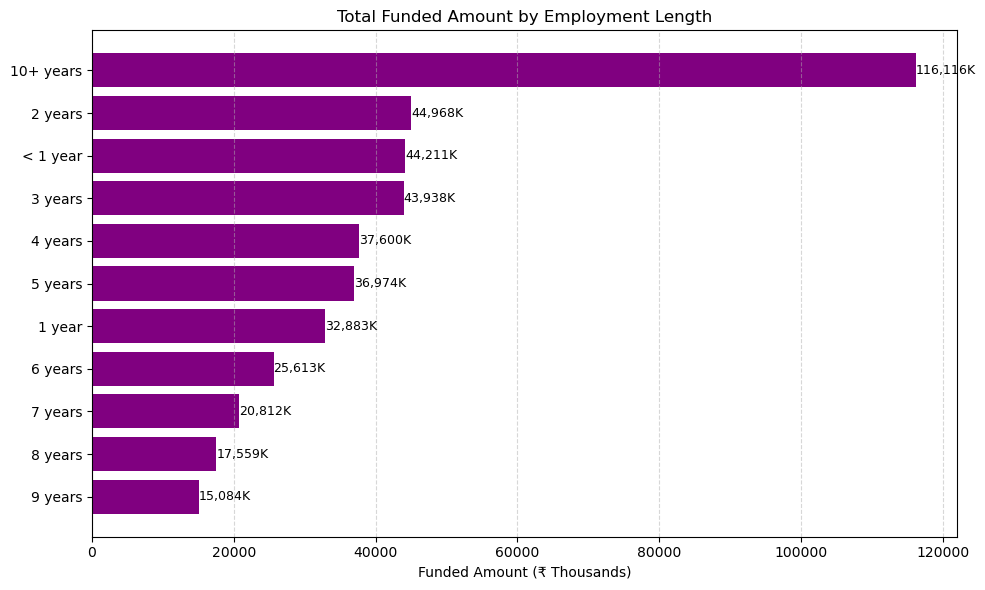

In [29]:
emp_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding.index, emp_funding, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K',
             va='center',
             fontsize=9)

plt.xlabel('Funded Amount (₹ Thousands)')
plt.title('Total Funded Amount by Employment Length')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Employee Length By Total Amount Received

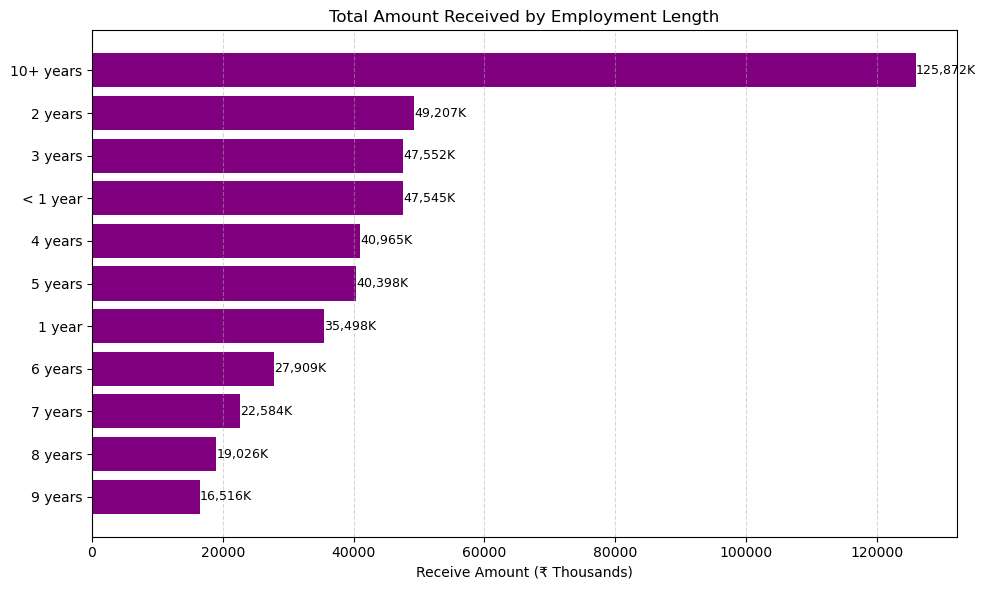

In [33]:
emp_received = df.groupby('emp_length')['total_payment'].sum().sort_values()/1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_received.index, emp_received, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K',
             va='center',
             fontsize=9)

plt.xlabel('Receive Amount (₹ Thousands)')
plt.title('Total Amount Received by Employment Length')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Employee Length By Total Loan Applications

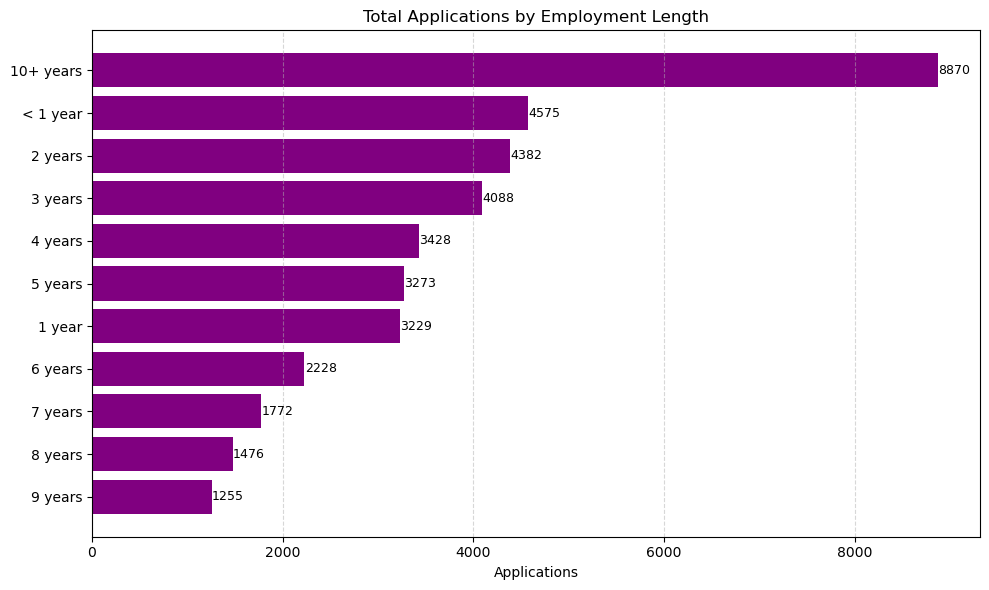

In [50]:
emp_application = df.groupby('emp_length')['id'].count().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_application.index, emp_application, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height() / 2,
             f'{int(width)}',
             va='center',
             fontsize=9)

plt.xlabel('Applications')
plt.title('Total Applications by Employment Length')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose By Total Funded Amount

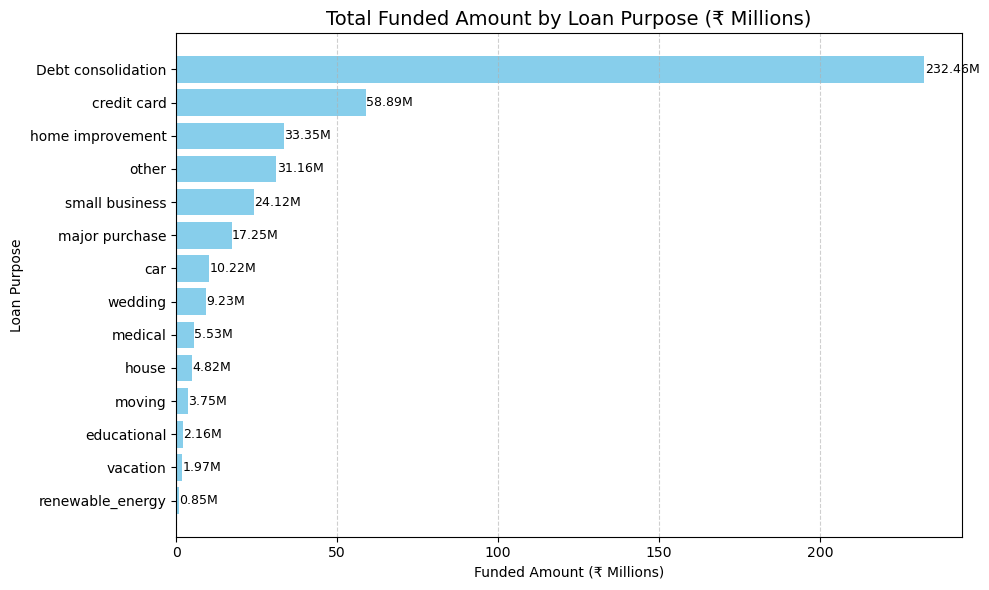

In [36]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values() / 1000000)

plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_funding_millions.index,
                purpose_funding_millions.values,
                color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1,
             bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}M',
             va='center',
             fontsize=9)

plt.title('Total Funded Amount by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Funded Amount (₹ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Loan Purpose By Total Received Amount 

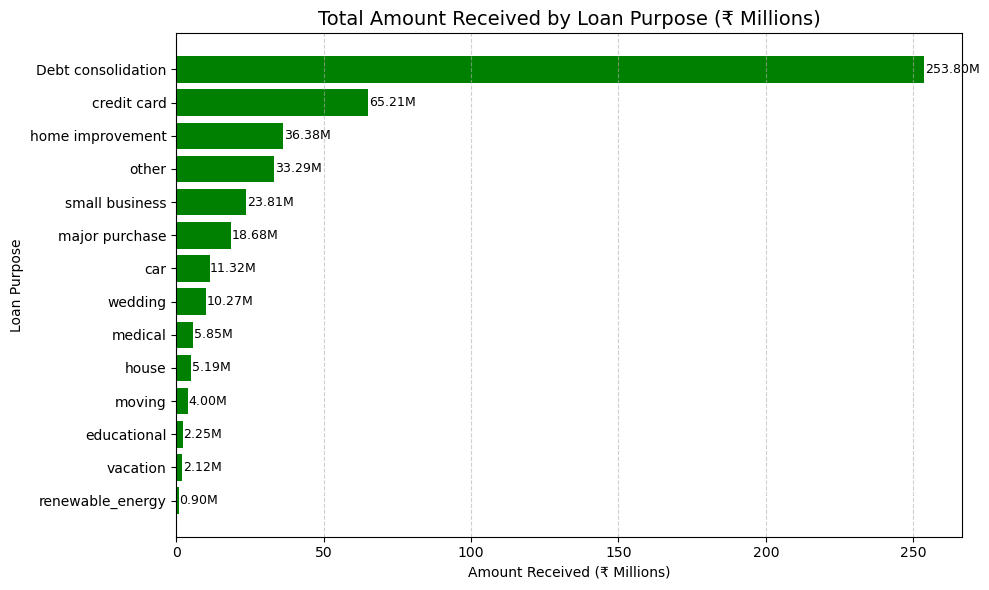

In [38]:
purpose_amount_millions = (df.groupby('purpose')['total_payment'].sum().sort_values() / 1000000)

plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_amount_millions.index,
                purpose_amount_millions.values,
                color='green')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1,
             bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}M',
             va='center',
             fontsize=9)

plt.title('Total Amount Received by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Amount Received (₹ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Loan Purpose By Total Applications

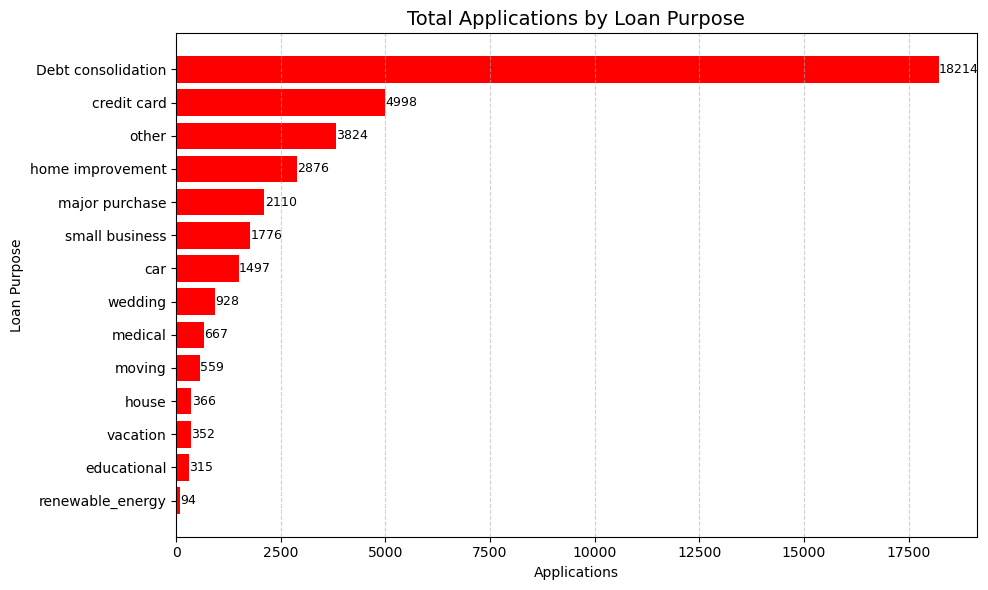

In [49]:
purpose_applications = df.groupby('purpose')['id'].count().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_applications.index,
                purpose_applications.values,
                color='red')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height() / 2,
             f'{int(width)}',
             va='center',
             fontsize=9)

plt.title('Total Applications by Loan Purpose', fontsize=14)
plt.xlabel('Applications')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Home Ownership By Total Funded Amount

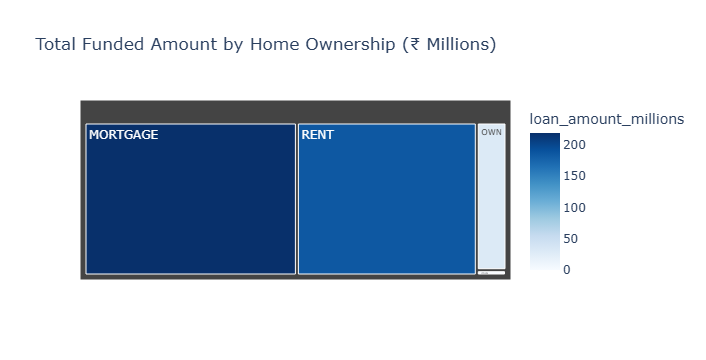

In [42]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1_000_000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)

fig.show()

### Home Ownership By Total Amount Received

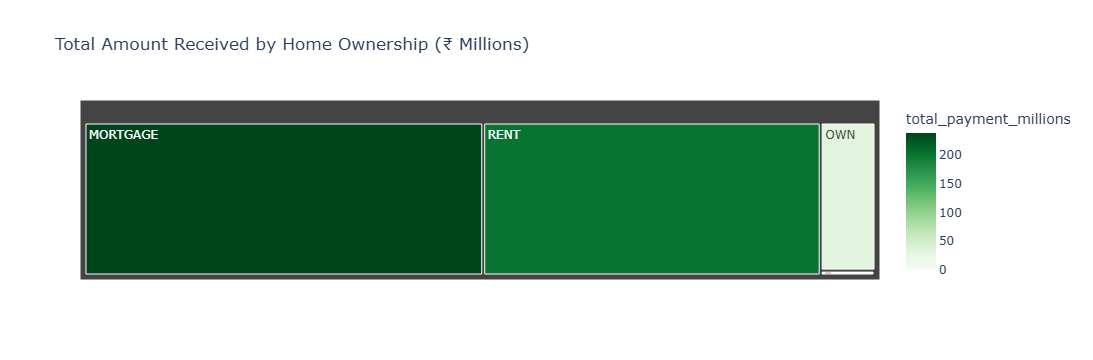

In [45]:
home_received = df.groupby('home_ownership')['total_payment'].sum().reset_index()
home_received['total_payment_millions'] = home_received['total_payment'] / 1_000_000

fig = px.treemap(
    home_received,
    path=['home_ownership'],
    values='total_payment_millions',
    color='total_payment_millions',
    color_continuous_scale='Greens',
    title='Total Amount Received by Home Ownership (₹ Millions)'
)

fig.show()

### Home Ownership By Total Loan Applications

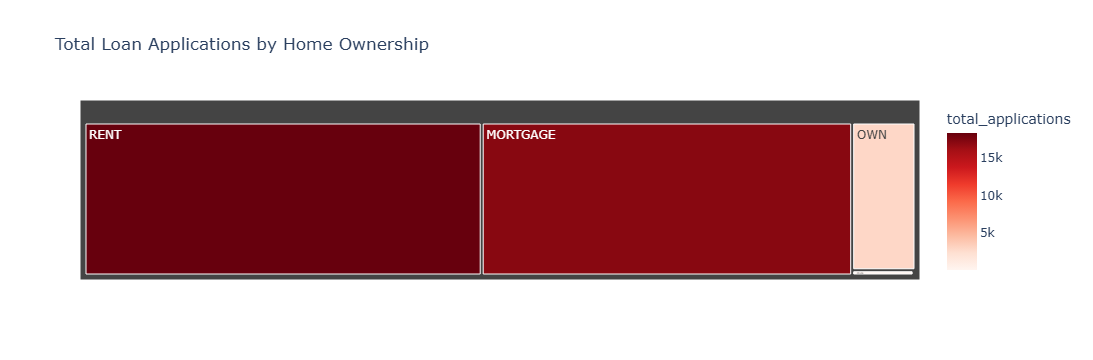

In [55]:
home_applications = df.groupby('home_ownership')['id'].count().reset_index()
home_applications.rename(columns={'id': 'total_applications'}, inplace=True)

fig = px.treemap(
    home_applications,
    path=['home_ownership'],
    values='total_applications',
    color='total_applications',
    color_continuous_scale='Reds',
    title='Total Loan Applications by Home Ownership'
)

fig.show()